# Creating plot for average spectral lengths


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
print(torch.cuda.is_available)
from detecto import core, utils
from detecto.visualize import show_labeled_image
from sklearn.preprocessing import MinMaxScaler


<function is_available at 0x7f2a7ad05b40>


In [1]:
# wavebands from Specim IQ camera

wavebands = ['397.32', '400.20', '403.09', '405.97', '408.85', '411.74', '414.63', '417.52', '420.40', '423.29', '426.19', '429.08', '431.97', '434.87', '437.76', '440.66', '443.56', '446.45', '449.35', '452.25', '455.16', '458.06', '460.96', '463.87', '466.77', '469.68', '472.59', '475.50', '478.41', '481.32', '484.23', '487.14', '490.06', '492.97', '495.89', '498.80', '501.72', '504.64', '507.56', '510.48', '513.40', '516.33', '519.25', '522.18', '525.10', '528.03', '530.96', '533.89', '536.82', '539.75', '542.68', '545.62', '548.55', '551.49', '554.43', '557.36', '560.30', '563.24', '566.18', '569.12', '572.07', '575.01', '577.96', '580.90', '583.85', '586.80', '589.75', '592.70', '595.65', '598.60', '601.55', '604.51', '607.46', '610.42', '613.38', '616.34', '619.30', '622.26', '625.22', '628.18', '631.15', '634.11', '637.08', '640.04', '643.01', '645.98', '648.95', '651.92', '654.89', '657.87', '660.84', '663.81', '666.79', '669.77', '672.75', '675.73', '678.71', '681.69', '684.67', '687.65', '690.64', '693.62', '696.61', '699.60', '702.58', '705.57', '708.57', '711.56', '714.55', '717.54', '720.54', '723.53', '726.53', '729.53', '732.53', '735.53', '738.53', '741.53', '744.53', '747.54', '750.54', '753.55', '756.56', '759.56', '762.57', '765.58', '768.60', '771.61', '774.62', '777.64', '780.65', '783.67', '786.68', '789.70', '792.72', '795.74', '798.77', '801.79', '804.81', '807.84', '810.86', '813.89', '816.92', '819.95', '822.98', '826.01', '829.04', '832.07', '835.11', '838.14', '841.18', '844.22', '847.25', '850.29', '853.33', '856.37', '859.42', '862.46', '865.50', '868.55', '871.60', '874.64', '877.69', '880.74', '883.79', '886.84', '889.90', '892.95', '896.01', '899.06', '902.12', '905.18', '908.24', '911.30', '914.36', '917.42', '920.48', '923.55', '926.61', '929.68', '932.74', '935.81', '938.88', '941.95', '945.02', '948.10', '951.17', '954.24', '957.32', '960.40', '963.47', '966.55', '969.63', '972.71', '975.79', '978.88', '981.96', '985.05', '988.13', '991.22', '994.31', '997.40', '1000.49', '1003.58']

In [25]:
wavebands[19]

'452.25'

# Make sure makesense AI is working correctly

In [5]:
# This extracts the coordinates of the bounding boxes for each apple for each image

c = 0
thresh = 0.8

# image_name is the image_file_name in the csv file
# loc_link is the folder location of the image 

def extractor(image_name, model, loc_link):
    global c

    c += 1
    print(c)
    folder_link = "/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/"
    folder_link = folder_link
        
    # image_link = folder_link + image_name
    

    image_link = folder_link + loc_link + '/' 
    image_link_path = image_link + image_name

    # print(image_link_path)
    
    # image = utils.read_image(image_link)


    # image_path = os.path(image_link_path)
    image = utils.read_image(image_link_path)

    predictions = model.predict(image)
    labels, boxes, scores = predictions
    # show_labeled_image(image, boxes, labels)

    filtered_indices = np.where(scores > thresh)
    filtered_scores = scores[filtered_indices]
    filtered_boxes = boxes[filtered_indices]
    num_list = filtered_indices[0].tolist()
    filtered_labels = [labels[i] for i in num_list]
    # show_labeled_image(image, filtered_boxes, filtered_labels)

    # tenosrs are sorted on their y position  - e.g they are sorted from top to bottom
    sorted_tensor = filtered_boxes[np.lexsort((filtered_boxes[:, 1],))]

    # for when there are odd number of apples (boxes) and more than 3 apples
    if len(filtered_boxes) > 3 and len(filtered_boxes) % 2 == 0:

        # Determine the number of rows in the sorted tensor
        num_rows = int(len(sorted_tensor) / 2)

        # Sort each row from left to right (based on xmin)
        sorted_tensor = torch.tensor(
            np.concatenate(
                [
                    sorted_tensor[i : i + num_rows, :][
                        np.lexsort((sorted_tensor[i : i + num_rows, 0],))
                    ]
                    for i in range(0, len(sorted_tensor), num_rows)
                ]
            )
        )
    # for when there are even number of apples (boxes) and more than 3 apples
    elif len(filtered_boxes) > 3 and len(filtered_boxes) % 2 != 0:

        # Determine the number of rows in the sorted tensor
        num_rows = int(len(sorted_tensor) / 2) + 1

        # Sort each row from left to right (based on xmin)
        sorted_tensor = torch.tensor(
            np.concatenate(
                [
                    sorted_tensor[i : i + num_rows, :][np.lexsort((sorted_tensor[i : i + num_rows, 0],))]
                    for i in range(0, len(sorted_tensor), num_rows)
                ]
            )
        )

    # for when there are less than 4 apples
    elif len(filtered_boxes) < 4:

        coordinates = [(box[0], box[1], box[2], box[3]) for box in filtered_boxes]

        # Step 2: Calculate center points
        center_points = [
            (0.5 * (x1 + x2), 0.5 * (y1 + y2)) for (x1, y1, x2, y2) in coordinates
        ]

        # Step 3: Sort bounding boxes based on x-coordinate of center point
        sorted_indices = sorted(
            range(len(center_points)), key=lambda k: center_points[k][0]
        )
        sorted_coordinates = [coordinates[i] for i in sorted_indices]

        # Step 4: Update the original tensor list
        sorted_tensor = [torch.tensor(coord) for coord in sorted_coordinates]

    return sorted_tensor

In [ ]:

data_NZ2023 = pd.read_pickle('/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/data_NZ2023_a_final2.pkl')
data_NZ2024 = pd.read_pickle('/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/data_NZ2024_a_final2.pkl')
data_UK2024 = pd.read_pickle('/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/Pickle_files/data_UK2024_a_final2.pkl')

data_NZ2023.reset_index(drop = True, inplace = True)
data_NZ2024.reset_index(drop = True, inplace = True)
data_UK2024.reset_index(drop = True, inplace = True)


In [4]:
print(data_NZ2023.tail())
print(data_NZ2024.tail())
print(data_UK2024.tail())

import random
np.random.seed(779)
random.seed(779)
index = random.randint(1, 250)
print(index)

                                        Image_folder_A    image_filename_A  \
280  20230404 Braeburn TG/2023-04-04_017/2023-04-04...  2023-04-04_017.png   
281  20230404 Braeburn TG/2023-04-04_021/2023-04-04...  2023-04-04_021.png   
282  20230404 Braeburn TG/2023-04-04_025/2023-04-04...  2023-04-04_025.png   
283  20230404 Braeburn TG/2023-04-04_029/2023-04-04...  2023-04-04_029.png   
284  20230404 Braeburn TG/2023-04-04_033/2023-04-04...  2023-04-04_033.png   

                ID  Number  Firmness1  Firmness2   Brix  Starch  Starch2  \
280  Braeburn_1673    19.0       7.34       7.15  11.33    60.0      7.0   
281  Braeburn_1679    25.0       7.55       7.42  11.33    45.0      8.0   
282  Braeburn_1685    31.0       9.05       7.40  13.46    86.0      3.0   
283  Braeburn_1691    37.0       7.55       7.88  11.66    82.0      4.0   
284  Braeburn_1697    43.0       6.73       7.67  12.11    43.0      8.0   

       Streif  Avg_firmness  Cultivar  \
280  4.476169         7.245  Brae

In [8]:
# From the sorted tensor, print images
NZ2023_test = data_NZ2023.loc[index,['Image_folder_A', 'Cultivar', 'sorted_tensor']]
NZ2024_test = data_NZ2024.loc[index,['Image_folder_A', 'Cultivar', 'sorted_tensor']]
UK2024_test = data_UK2024.loc[index,['Image_folder_A', 'Cultivar', 'sorted_tensor']]

print(NZ2023_test)
print(NZ2024_test)
print(UK2024_test)

Image_folder_A    20230308 09 Cox/2023-03-08_044/2023-03-08_044.png
Cultivar                                        Cox's Orange Pippin
sorted_tensor     [[tensor(14.2925), tensor(176.1646), tensor(12...
Name: 145, dtype: object
Image_folder_A    20240404 Fuji Breeding team/2024-04-04_011/202...
Cultivar                                                       Fuji
sorted_tensor     [[tensor(12.5633), tensor(70.5328), tensor(181...
Name: 145, dtype: object
Image_folder_A               20241002BraeburnFujiGDGala/680/680.png
Cultivar                                                   Braeburn
sorted_tensor     [[tensor(25.7864), tensor(70.3527), tensor(143...
Name: 145, dtype: object


In [9]:
file_path = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/'
NZ2023_test_img = utils.read_image(f'{file_path}spectral_NZ_2023/{NZ2023_test["Image_folder_A"]}')
NZ2024_test_img = utils.read_image(f'{file_path}spectral_NZ_2024/{NZ2024_test["Image_folder_A"]}')
UK2024_test_img = utils.read_image(f'{file_path}spectral_UK_2024/{UK2024_test["Image_folder_A"]}')

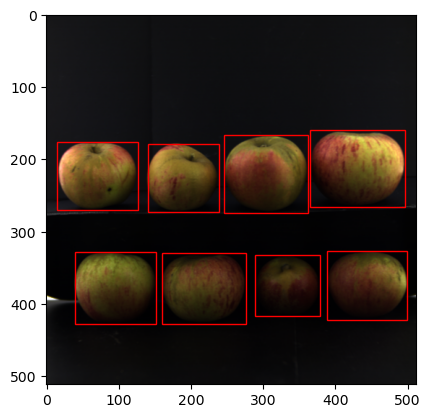

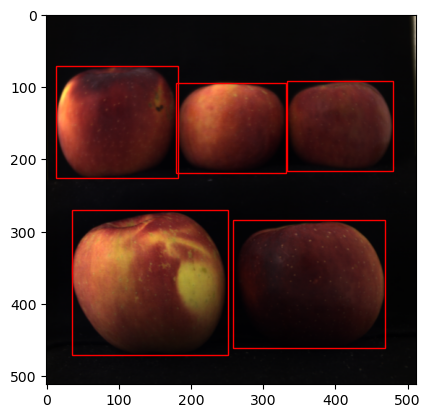

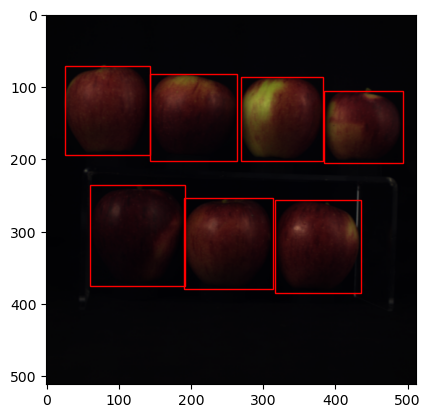

In [10]:
# All tensors are correct
show_labeled_image(NZ2023_test_img, NZ2023_test['sorted_tensor'])
show_labeled_image(NZ2024_test_img, NZ2024_test['sorted_tensor'])
show_labeled_image(UK2024_test_img, UK2024_test['sorted_tensor'])

In [11]:
# For the first apple from each image, locally average the apples so that they result in 50x50px image then cut 5px off each edge

NZ2023_tensor = NZ2023_test['sorted_tensor'][0]
NZ2024_tensor = NZ2024_test['sorted_tensor'][0]
UK2024_tensor = UK2024_test['sorted_tensor'][0]
print(UK2024_tensor)

aggregate_pixel_width = 50
aggregate_pixel_height = 50

test_tensors = [NZ2023_tensor, NZ2024_tensor, UK2024_tensor]
test_images = [NZ2023_test_img, NZ2024_test_img, UK2024_test_img]

processed_images = []
file_metadata = []

for i in range(3):
            x1, y1, x2, y2 = map(int, test_tensors[i])
            image_segment = test_images[i][y1:y2, x1:x2]

            h, w, c = image_segment.shape

            # Compute pixels to remove for divisibility by aggregate pixel size
            remove_h = h % aggregate_pixel_height
            remove_w = w % aggregate_pixel_width

            # Crop from edges to prioritize the center
            top_crop = remove_h // 2
            bottom_crop = remove_h - top_crop
            left_crop = remove_w // 2
            right_crop = remove_w - left_crop

            # Apply cropping
            image_segment = image_segment[top_crop:h-bottom_crop, left_crop:w-right_crop]

            # Ensure dimensions are now divisible by aggregate pixel size
            h, w, c = image_segment.shape
            assert h % aggregate_pixel_height == 0 and w % aggregate_pixel_width == 0, "Cropping failed!"

            # Compute block size
            block_h, block_w = h // aggregate_pixel_height, w // aggregate_pixel_width

            # Initialize aggregated array
            aggregated_array = np.zeros((aggregate_pixel_height, aggregate_pixel_width, c), dtype=int)

            # Perform pixel aggregation
            for m in range(aggregate_pixel_height):
                for n in range(aggregate_pixel_width):
                    y_start, y_end = m * block_h, (m + 1) * block_h
                    x_start, x_end = n * block_w, (n + 1) * block_w

                    # Average pooling
                    block = image_segment[y_start:y_end, x_start:x_end]
                    aggregated_array[m, n] = np.mean(block, axis=(0, 1))

                
            processed_images.append(aggregated_array)
            file_metadata.append(test_images)



tensor([ 25.7864,  70.3527, 143.0027, 193.2524])


In [12]:
print(processed_images[1].shape)
print(processed_images[2])

(50, 50, 3)
[[[ 4  4  6]
  [ 4  4  7]
  [ 4  4  6]
  ...
  [ 6  4  7]
  [ 4  4  7]
  [ 4  4  6]]

 [[ 4  4  6]
  [ 4  4  6]
  [ 4  4  6]
  ...
  [16  5  7]
  [ 6  4  7]
  [ 4  4  6]]

 [[ 4  4  6]
  [ 4  4  6]
  [ 5  4  6]
  ...
  [25  6  8]
  [15  5  7]
  [ 5  4  6]]

 ...

 [[ 3  3  5]
  [ 3  3  5]
  [ 3  3  5]
  ...
  [ 3  3  6]
  [ 3  3  7]
  [ 3  3  6]]

 [[ 3  3  5]
  [ 3  3  5]
  [ 3  3  5]
  ...
  [ 3  3  6]
  [ 3  3  6]
  [ 3  3  6]]

 [[ 3  3  5]
  [ 3  3  5]
  [ 3  3  5]
  ...
  [ 3  3  6]
  [ 3  3  6]
  [ 3  3  6]]]


In [13]:
print(len(processed_images))

3


In [14]:
 # Print the range of values after normalization

for i in range(3):
    print(f"Processed Image {i+1} - Min Value: {np.min(processed_images[i])}, Max Value: {np.max(processed_images[i])}")

Processed Image 1 - Min Value: 6, Max Value: 255
Processed Image 2 - Min Value: 2, Max Value: 255
Processed Image 3 - Min Value: 2, Max Value: 112


In [15]:
print(processed_images[0].shape)

(50, 50, 3)


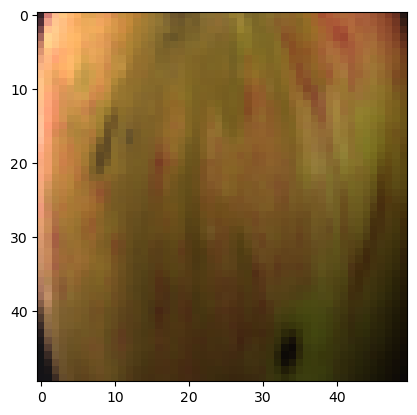

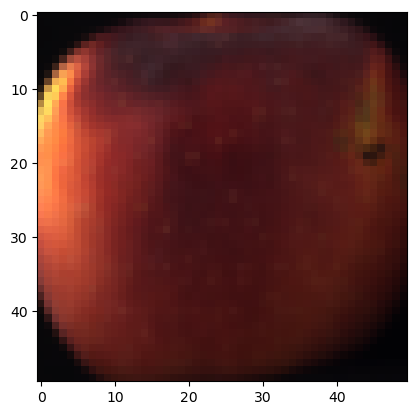

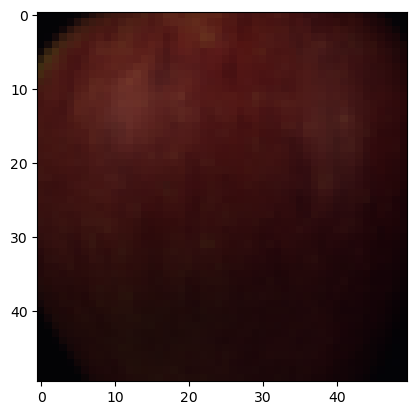

In [16]:
# image processingcorrectly isolates the central part ofeach apple. (Using RGB images to visualise the process of the hyperspectral data)
for i in range(3):
    plt.imshow(processed_images[i])
    plt.show()


In [17]:
# RGB images

test_mean_spectra = []

for i in range(3):
    mean_spectra = np.mean(processed_images[i], axis=(0,1))
    test_mean_spectra.append(mean_spectra)

print(test_mean_spectra)

normalised_test_mean_spectra = []
for i in range(3):
    normalised_spectrum = test_mean_spectra[i].astype(np.float32) / 255.0
    normalised_test_mean_spectra.append(normalised_spectrum)


print(normalised_test_mean_spectra)



[array([120.1088,  88.0064,  38.2128]), array([84.6056, 31.008 , 27.1764]), array([51.7664, 16.138 , 15.3712])]
[array([0.47101492, 0.34512314, 0.14985411], dtype=float32), array([0.33178666, 0.12159999, 0.10657412], dtype=float32), array([0.2030055 , 0.06328627, 0.06027921], dtype=float32)]


In [58]:
# Convert the list of arrays to a numpy array for easier manipulation
rgb_image_array = np.array(normalised_test_mean_spectra)

# Find the max and min values for each R, G, and B
red_max = np.max(rgb_image_array[:, 0])
red_min = np.min(rgb_image_array[:, 0])

green_max = np.max(rgb_image_array[:, 1])
green_min = np.min(rgb_image_array[:, 1])

blue_max = np.max(rgb_image_array[:, 2])
blue_min = np.min(rgb_image_array[:, 2])

print(f"Red max: {red_max}, Red min: {red_min}")
print(f"Green max: {green_max}, Green min: {green_min}")
print(f"Blue max: {blue_max}, Blue min: {blue_min}")

Red max: 0.47101491689682007, Red min: 0.20300549268722534
Green max: 0.34512314200401306, Green min: 0.06328627467155457
Blue max: 0.14985410869121552, Blue min: 0.06027921289205551


In [ ]:
# import numpy as np
# raw = np.fromfile('/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/20230328 Fuji PFR orchard early pick/2023-03-28_002/capture/2023-03-28_002.raw', dtype = np.uint16)
# white = np.fromfile('/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/20230328 Fuji PFR orchard early pick/2023-03-28_002/capture/WHITEDARKREF_2023-03-28_002.raw', dtype = np.float32)
# dark = np.fromfile('/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/20230328 Fuji PFR orchard early pick/2023-03-28_002/capture/WHITEDARKREF_2023-03-28_002.raw', dtype = np.float32)

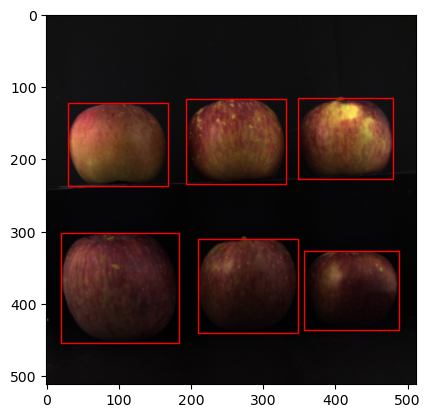

In [ ]:
# print the RGB (reading from png)
test_RGB = utils.read_image(f'{file_path}spectral_NZ_2023/{data_NZ2023["Image_folder_A"][0]}')
show_labeled_image(test_RGB, data_NZ2023['sorted_tensor'][0])

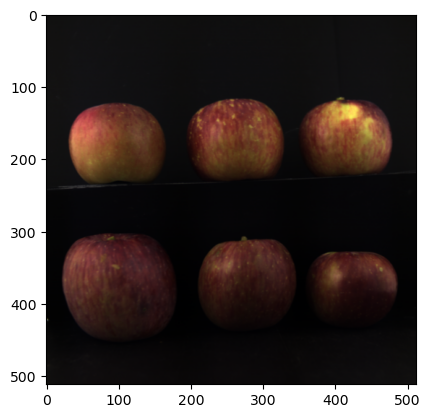

In [44]:
# PNG file

png_file = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/20230328 Fuji PFR orchard early pick/2023-03-28_002/results/REFLECTANCE_2023-03-28_002.png'

test_RGB = utils.read_image(png_file)
plt.imshow(test_RGB)
plt.show()

Max value: 1.9682725667953491, Min value: 0.0
Max value: 1.9682725667953491, Min value: 0.0
Max value: 1.0, Min value: 0.0


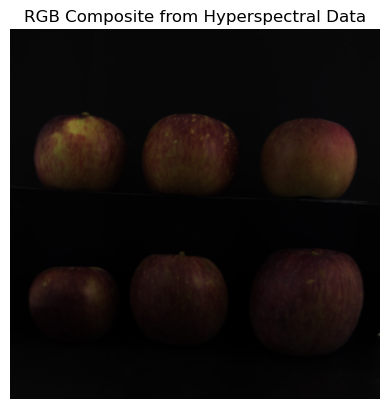

In [11]:
# jeff test
import numpy as np
import matplotlib.pyplot as plt
import imageio

file_path = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2023/20230328 Fuji PFR orchard early pick/2023-03-28_002/results/REFLECTANCE_2023-03-28_002.dat'
height, width, bands = 512, 512, 204
dtype = np.dtype('float32')  # Little-endian 16-bit

# Load and reshape (BIL format)
raw_data = np.fromfile(file_path, dtype=dtype)
print(f'Max value: {np.max(raw_data)}, Min value: {np.min(raw_data)}')
data = raw_data.reshape((height, bands, width))
data = np.transpose(data, (2, 0, 1))  # Convert to (H, W, B)

# Convert to float and normalize
print(f'Max value: {np.max(data)}, Min value: {np.min(data)}')
data = data.astype(np.float32) / 65535.0
data = (data - data.min()) / (data.max() - data.min())
print(f'Max value: {np.max(data)}, Min value: {np.min(data)}')

# Extract RGB bands
red_band = data[:, :, 69]
green_band = data[:, :, 52]
blue_band = data[:, :, 18]

# Stack into RGB image
rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

# Display image
plt.imshow(rgb_image)
plt.axis("off")
plt.title("RGB Composite from Hyperspectral Data")
plt.show()


In [17]:
test_tensor = data_NZ2023['sorted_tensor'][0]
print(test_tensor)
height = 512
width = 512
aggregate_pixel_height = 50
aggregate_pixel_width = 50
# spectral_data = raw
# bands = len(spectral_data) // (height * width)
# spectral_data = spectral_data.reshape(height, width, bands)
spectral_data = data

print(f"Loaded dat file in float32 format - Min Value: {np.min(spectral_data)}, Max Value: {np.max(spectral_data)}")



# Process each bounding box in "sorted_tensor"
for region in test_tensor:
    x1, y1, x2, y2 = map(int, region)
    image_segment = spectral_data[y1:y2, x1:x2]
    h, w, c = image_segment.shape
    # Compute pixels to remove for divisibility by aggregate pixel size
    remove_h = h % aggregate_pixel_height
    remove_w = w % aggregate_pixel_width
    # Crop from edges to prioritize the center
    top_crop = remove_h // 2
    bottom_crop = remove_h - top_crop
    left_crop = remove_w // 2
    right_crop = remove_w - left_crop
    # Apply cropping
    image_segment = image_segment[top_crop:h-bottom_crop, left_crop:w-right_crop]
    # Ensure dimensions are now divisible by aggregate pixel size
    h, w, c = image_segment.shape
    assert h % aggregate_pixel_height == 0 and w % aggregate_pixel_width == 0, "Cropping failed!"
    # Compute block size
    block_h, block_w = h // aggregate_pixel_height, w // aggregate_pixel_width
    # Initialize aggregated array
    aggregated_array = np.zeros((aggregate_pixel_height, aggregate_pixel_width, c), dtype=np.float32)
    # Perform pixel aggregation
    for m in range(aggregate_pixel_height):
        for n in range(aggregate_pixel_width):
            y_start, y_end = m * block_h, (m + 1) * block_h
            x_start, x_end = n * block_w, (n + 1) * block_w
            # Average pooling
            block = image_segment[y_start:y_end, x_start:x_end]
            aggregated_array[m, n] = np.mean(block, axis=(0, 1))

tensor([[ 29.8971, 121.5800, 167.9783, 236.8696],
        [192.8034, 115.6603, 331.1520, 233.5127],
        [348.0719, 115.1191, 480.0935, 226.7384],
        [ 20.3844, 301.3976, 183.5440, 454.6985],
        [209.4115, 310.2642, 347.4362, 440.2166],
        [356.7486, 326.3894, 487.3820, 436.2872]])
Loaded dat file in float32 format - Min Value: 0.0, Max Value: 1.0


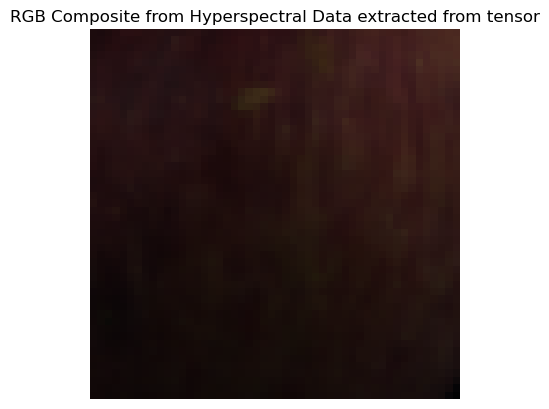

In [ ]:
# Print aggregated rgb image
# Extract RGB bands
red_band = aggregated_array[:, :, 69]
green_band = aggregated_array[:, :, 52]
blue_band = aggregated_array[:, :, 18]

rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

# Display image
plt.imshow(rgb_image)
plt.axis("off")
plt.title("RGB Composite from Hyperspectral Data extracted from tensor")
plt.show()


    wavebands  reflectance
0      397.32     0.234176
1      400.20     0.210031
2      403.09     0.181759
3      405.97     0.161766
4      408.85     0.141009
..        ...          ...
199    991.22     0.331045
200    994.31     0.334433
201    997.40     0.335812
202   1000.49     0.339944
203   1003.58     0.343902

[204 rows x 2 columns]


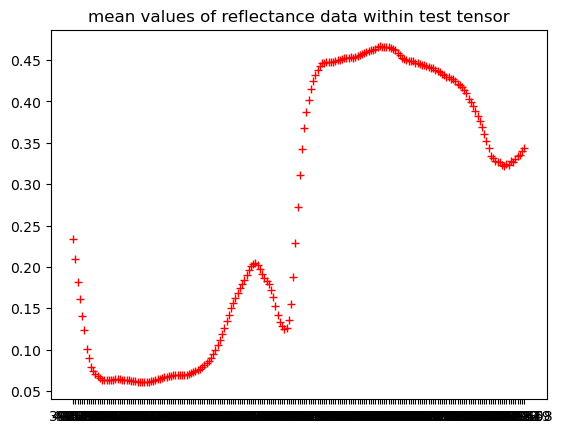

In [20]:
import numpy as np
import matplotlib.pyplot as plt
test_mean_spectra = np.mean(aggregated_array, axis=(0,1))

test_mean_spectra_df = pd.DataFrame(test_mean_spectra)
wavebands_df = pd.DataFrame(wavebands)
test_mean_spectra_df = pd.concat([wavebands_df, test_mean_spectra_df], axis = 1)
test_mean_spectra_df.columns = ['wavebands', 'reflectance']
print(test_mean_spectra_df)



plt.plot(test_mean_spectra_df['wavebands'], test_mean_spectra_df['reflectance'], 'r+')
plt.title('mean values of reflectance data within test tensor')
plt.show()

[(14, 42), (40, 28), (30, 34), (13, 21), (14, 14), (6, 42), (6, 48), (13, 31), (48, 21), (35, 33)]


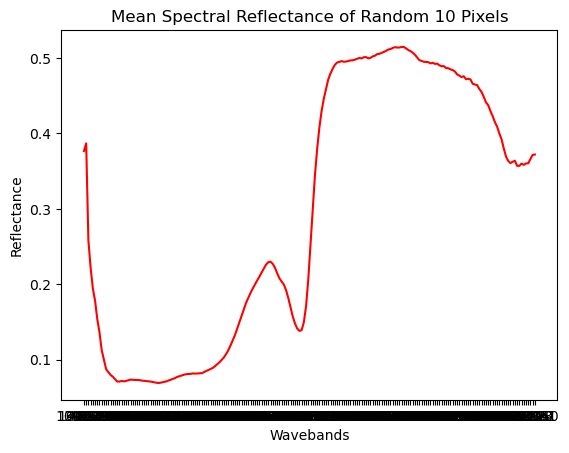

In [21]:
# 10 random pixels

import random

# Initialize an empty DataFrame to store all pixel spectra

# np.random.seed(779)
# random.seed(779)
all_pixel_spectra_df = pd.DataFrame()

# Get random 10 pixels from the spectral data
random_pixels = np.random.choice(aggregated_array.shape[0] * aggregated_array.shape[1], 10, replace=False)
random_pixel_indices = [(idx // aggregated_array.shape[1], idx % aggregated_array.shape[1]) for idx in random_pixels]

print(random_pixel_indices)
# Iterate over each random pixel
for i, j in random_pixel_indices:
    test_pixel = aggregated_array[i][j]
    test_pixel_df = pd.DataFrame(test_pixel)
    wavebands_df = pd.DataFrame(wavebands)
    test_pixel_spectra_df = pd.concat([wavebands_df, test_pixel_df], axis=1)
    test_pixel_spectra_df.columns = ['wavebands', 'reflectance']
    
    # Append the pixel spectra to the main DataFrame
    all_pixel_spectra_df = pd.concat([all_pixel_spectra_df, test_pixel_spectra_df])

# Calculate the mean reflectance for each waveband
mean_reflectance_df = all_pixel_spectra_df.groupby('wavebands').mean().reset_index()

# Plot the mean reflectance for each waveband
plt.plot(mean_reflectance_df['wavebands'], mean_reflectance_df['reflectance'], 'r-')
plt.xlabel('Wavebands')
plt.ylabel('Reflectance')
plt.title('Mean Spectral Reflectance of Random 10 Pixels')
plt.show()

In [34]:
# Visualise current data
current_data = np.fromfile("/media/2tbdisk2/data/Haidee_apple_data/Haidee/Data_outputs_NZ2023/Spectral/aggregated_50px_HSI/NZ2023/50px_Braeburn_1655_3341.npy", dtype=np.float32)
print(f'dtype: {current_data.dtype}, Max value: {np.max(current_data)}, Min value: {np.min(current_data)}, Shape: {current_data.shape}')

height = 50
width = 50

bands = len(current_data) // (height * width)
current_data = current_data.reshape((height, bands, width))
current_data = np.transpose(current_data, (2, 0, 1))  # Convert to (H, W, B)



# Print aggregated rgb image
# Extract RGB bands
red_band = current_data[:, :, 69]
green_band = current_data[:, :, 52]
blue_band = current_data[:, :, 18]

rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

# Display image
plt.imshow(rgb_image)
plt.axis("off")
plt.title("RGB Composite from Hyperspectral Data extracted from tensor")
plt.show()


dtype: float32, Max value: 1.330661074788474e+37, Min value: 1.2387478424631383e-40, Shape: (510032,)


ValueError: cannot reshape array of size 510032 into shape (50,204,50)

[(40, 42), (28, 9), (2, 5), (48, 30), (36, 40), (45, 48), (29, 35), (47, 26), (10, 20), (40, 27)]


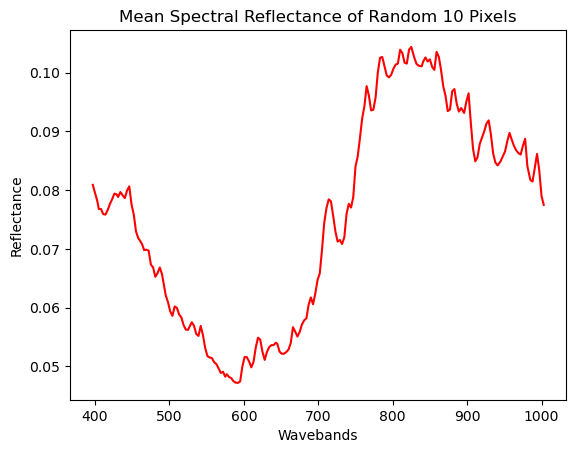

In [ ]:
# 10 random pixels

import random

# Initialize an empty DataFrame to store all pixel spectra

# np.random.seed(779)
# random.seed(779)
all_pixel_spectra_df = pd.DataFrame()

# Get random 10 pixels from the spectral data
random_pixels = np.random.choice(images_NZ2023_test[0].shape[0] * images_NZ2023_test[0].shape[1], 10, replace=False)
random_pixel_indices = [(idx // images_NZ2023_test[0].shape[1], idx % images_NZ2023_test[0].shape[1]) for idx in random_pixels]

print(random_pixel_indices)
# Iterate over each random pixel
for i, j in random_pixel_indices:
    test_pixel = images_NZ2023_test[0][i][j]
    test_pixel_df = pd.DataFrame(test_pixel)
    wavebands_df = pd.DataFrame(wavebands)
    test_pixel_spectra_df = pd.concat([wavebands_df, test_pixel_df], axis=1)
    test_pixel_spectra_df.columns = ['wavebands', 'reflectance']
    
    # Append the pixel spectra to the main DataFrame
    all_pixel_spectra_df = pd.concat([all_pixel_spectra_df, test_pixel_spectra_df])

# Calculate the mean reflectance for each waveband
mean_reflectance_df = all_pixel_spectra_df.groupby('wavebands').mean().reset_index()

# Plot the mean reflectance for each waveband
plt.plot(mean_reflectance_df['wavebands'], mean_reflectance_df['reflectance'], 'r-')
plt.xlabel('Wavebands')
plt.ylabel('Reflectance')
plt.title('Mean Spectral Reflectance of Random 10 Pixels')
plt.show()